In [ ]:
import glob
import numpy as np
import pandas as pd
from pyxcsao.crosscorrelate import PyXCSAO
from scipy.signal import medfilt
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.io import fits
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u
import lxml
import pickle
import xml.etree.ElementTree as ET
import time

In [2]:
def extract_1d_spectrum(path):
    '''get 1D spectrum from a fits file and return wavelength and flux arrays'''
    with fits.open(path) as hdul:
        flux = hdul['SCI'].data
        hdr = hdul['SCI'].header
        wcs = WCS(hdr)
        pix = np.arange(len(flux))
        wavelength = wcs.all_pix2world(pix, 0)[0]
    return wavelength, flux

In [99]:
def extract_1d_spectrum_2d(path, spat_min, spat_max):
    with fits.open(path) as hdul:
        flux2d = hdul['SCI'].data
        hdr    = hdul['SCI'].header
        wcs    = WCS(hdr)

        flux1d = flux2d[spat_min:spat_max+1, :].sum(axis=0)

        npix = flux2d.shape[1]
        pix  = np.arange(npix)
        
        # Build full coordinate array with zeros for unused axes
        coords = np.zeros((npix, wcs.naxis))
        coords[:, 0] = pix  # spectral axis
        world = wcs.all_pix2world(coords, 0)
        wavelength = world[:, 0]

    return wavelength, flux1d

In [3]:
spec_files = glob.glob('/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/*_1D*', recursive=True)
std_file = '/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/calibrations/processed_standard/S20250927S0030_standard.fits'
spec_files

['/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/S20250928S0033_1D.fits',
 '/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/S20250928S0047_1D.fits']

In [94]:
spec_files_2d = glob.glob('/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/*_2D*', recursive=True)
spec_files_2d

['/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/S20250928S0033_2D.fits',
 '/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/S20250928S0047_2D.fits']

In [95]:
for f in spec_files_2d:
    try:
        hdr0 = fits.getheader(f, 0)
        hdr1 = fits.getheader(f, 1)

        print(f)
        print("  OBJECT =", hdr0.get('OBJECT'))
        print("  OBSCLASS =", hdr0.get('OBSCLASS'))
        #print("  CCDSUM =", hdr1.get('CCDSUM'))
        print("  EXTNAME =", hdr1.get('EXTNAME'))
        print()

    except Exception as e:
        print(f)
        print("  ERROR:", e)
        print()

/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/S20250928S0033_2D.fits
  OBJECT = T1_dw1907m6357
  OBSCLASS = science
  EXTNAME = SCI

/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/S20250928S0047_2D.fits
  OBJECT = T1_nuc
  OBSCLASS = science
  EXTNAME = SCI



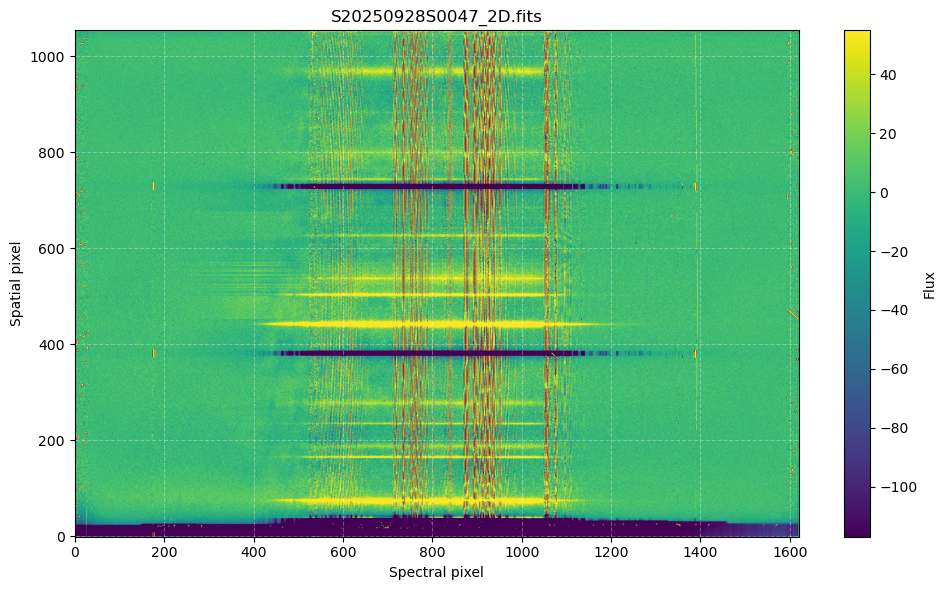

In [107]:
with fits.open(spec_files_2d[1]) as hdul:
    flux2d = hdul['SCI'].data

plt.figure(figsize=(10, 6))
plt.imshow(flux2d, aspect='auto', origin='lower', vmin=np.percentile(flux2d,5), vmax=np.percentile(flux2d, 95))
plt.colorbar(label='Flux')
plt.xlabel('Spectral pixel')
plt.ylabel('Spatial pixel')
plt.title(spec_files_2d[1].split('/')[-1])
plt.grid(True, color='white', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

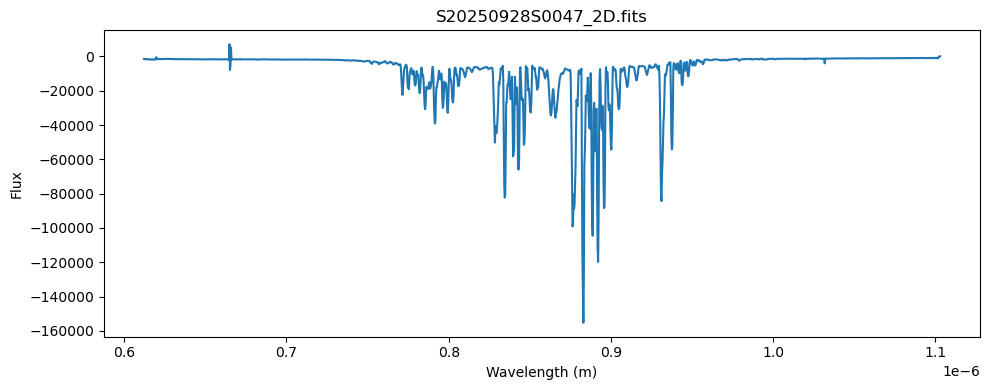

In [100]:
wavelength, flux = extract_1d_spectrum_2d(spec_files_2d[1], spat_min=0, spat_max=10)

plt.figure(figsize=(10, 4))
plt.plot(wavelength, flux)
plt.xlabel('Wavelength (m)')
plt.ylabel('Flux')
plt.title(spec_files_2d[1].split('/')[-1])
plt.tight_layout()
plt.show()

In [4]:
for f in spec_files:
    try:
        hdr0 = fits.getheader(f, 0)
        hdr1 = fits.getheader(f, 1)

        print(f)
        print("  OBJECT =", hdr0.get('OBJECT'))
        print("  OBSCLASS =", hdr0.get('OBSCLASS'))
        #print("  CCDSUM =", hdr1.get('CCDSUM'))
        print("  EXTNAME =", hdr1.get('EXTNAME'))
        print()

    except Exception as e:
        print(f)
        print("  ERROR:", e)
        print()

/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/S20250928S0033_1D.fits
  OBJECT = T1_dw1907m6357
  OBSCLASS = science
  EXTNAME = SCI

/Users/elliottburdett/research/neighborhood_watch/G-2025B-0505-V/dragons_v2/S20250928S0047_1D.fits
  OBJECT = T1_nuc
  OBSCLASS = science
  EXTNAME = SCI



In [5]:
T1_dw1907m6357_tbl = Table(extract_1d_spectrum(spec_files[0]), names=('lambda', 'flux'))
T1_nuc_tbl = Table(extract_1d_spectrum(spec_files[1]), names=('lambda', 'flux')) # this may be problematic because there are more entries than the other spectra (others are both 1595) ?
std_tbl = Table(extract_1d_spectrum(std_file), names=('lambda', 'flux'))

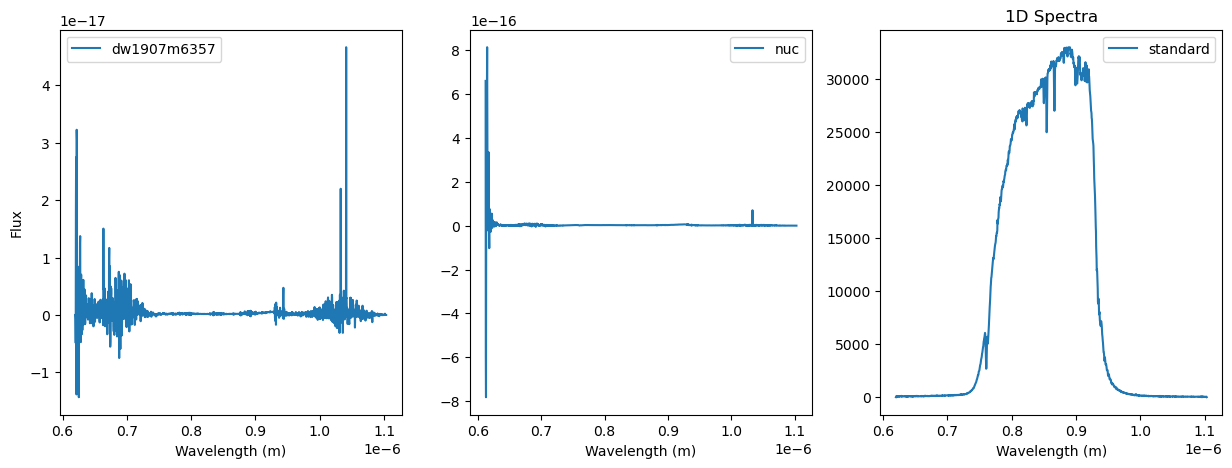

In [6]:
fig, axs = plt.subplots(1,3, figsize=(15,5))
axs[0].plot(T1_dw1907m6357_tbl['lambda'], T1_dw1907m6357_tbl['flux'], label='dw1907m6357')
axs[1].plot(T1_nuc_tbl['lambda'], T1_nuc_tbl['flux'], label='nuc')
axs[2].plot(std_tbl['lambda'], std_tbl['flux'], label='standard')
[axs[i].set_xlabel('Wavelength (m)') for i in range(3)]
axs[0].set_ylabel('Flux')
plt.title('1D Spectra')
[axs[i].legend() for i in range(3)]
plt.show()

### Try PyXCSAO on T1_dw

In [7]:
xc = PyXCSAO(
    st_lambda=6.5 * 10**-7,
    end_lambda=1 * 10**-6,
    minvel=-2000,
    maxvel=2000,
)

In [8]:
xc.data = xc.format_spectrum(T1_dw1907m6357_tbl["flux"], T1_dw1907m6357_tbl["lambda"])
hdul = fits.open(spec_files[0])
xc.meta = hdul[1].header

In [9]:
temp = xc.format_spectrum(std_tbl['flux'], std_tbl['lambda']) # template not temporary

grid = np.array([temp]) # take the one template and make it a grid of templates with one entry
teff = np.array([5000]) # assumptions
logg = np.array([4.5])
feh  = np.array([0.0])
alpha = np.array([0.0])

pickle.dump(
    [grid, teff, logg, feh, alpha, xc.la, "standard_star"],
    open("std_grid.pkl", "wb")
)

In [10]:
xc.add_grid(grid_pickle="std_grid.pkl")

In [11]:
t1dw_result = xc.run_XCSAO(run_subgrid=False)

In [ ]:
rv_t1dw  = t1dw_result["rv"] # rv km/s
erv_t1dw = t1dw_result["erv"] # rv error km/s
r_t1dw   = t1dw_result["r"] # Tonry & Davis R, signal-to-noise parameter of the correlation peak, higher is better.
print(f"Radial velocity of T1_dw1907m6357: {rv_t1dw:.2f} ± {erv_t1dw:.2f} km/s, R={r_t1dw:.2f}")

Radial velocity of T1_dw1907m6357: -1652.19 ± 107.67 km/s, R=0.37


### Try T1_nuc

In [13]:
nuc = PyXCSAO(
    st_lambda=6.5 * 10**-7,
    end_lambda=1 * 10**-6,
    minvel=-2000,
    maxvel=2000,
)
nuc.data = nuc.format_spectrum(T1_nuc_tbl["flux"], T1_nuc_tbl["lambda"])
hdul = fits.open(spec_files[1])
nuc.meta = hdul[1].header
nuc.add_grid(grid_pickle="std_grid.pkl")
nuc_result = nuc.run_XCSAO(run_subgrid=False)

In [ ]:
rv_nuc = nuc_result["rv"] # rv km/s
erv_nuc = nuc_result["erv"] # rv error km/s
r_nuc = nuc_result["r"] # Tonry & Davis R, signal-to-noise parameter of the correlation peak, higher is better.
print(f"Radial velocity of T1_nuc: {rv_nuc:.2f} ± {erv_nuc:.2f} km/s, R={r_nuc:.2f}")

Radial velocity of T1_nuc: 1850.03 ± 67.09 km/s, R=2.97


### Try Cutting the wavelength selection down to just the Calcium triplet

#### T1_dw:

In [15]:
xc = PyXCSAO(
    st_lambda=8 * 10**-7,
    end_lambda=9 * 10**-7,
    minvel=-2000,
    maxvel=2000,
)

In [16]:
xc.data = xc.format_spectrum(T1_dw1907m6357_tbl["flux"], T1_dw1907m6357_tbl["lambda"])
hdul = fits.open(spec_files[0])
xc.meta = hdul[1].header

In [17]:
temp = xc.format_spectrum(std_tbl['flux'], std_tbl['lambda']) # template not temporary

grid = np.array([temp]) # take the one template and make it a grid of templates with one entry
teff = np.array([5000]) # assumptions
logg = np.array([4.5])
feh  = np.array([0.0])
alpha = np.array([0.0])

pickle.dump(
    [grid, teff, logg, feh, alpha, xc.la, "standard_star"],
    open("std_grid.pkl", "wb")
)

In [18]:
xc.add_grid(grid_pickle="std_grid.pkl")

In [19]:
t1dw_result = xc.run_XCSAO(run_subgrid=False)

In [ ]:
rv_t1dw  = t1dw_result["rv"] # rv km/s
erv_t1dw = t1dw_result["erv"] # rv error km/s
r_t1dw   = t1dw_result["r"] # Tonry & Davis R, signal-to-noise parameter of the correlation peak, higher is better.
print(f"Radial velocity of T1_dw1907m6357: {rv_t1dw:.2f} ± {erv_t1dw:.2f} km/s, R={r_t1dw:.2f}")

Radial velocity of T1_dw1907m6357: 249.61 ± 57.85 km/s, R=1.57


### This is CRAZY DIFFERENT. Try on nuc:

In [21]:
nuc = PyXCSAO(
    st_lambda=8 * 10**-7,
    end_lambda=9 * 10**-7,
    minvel=-2000,
    maxvel=2000,
)
nuc.data = nuc.format_spectrum(T1_nuc_tbl["flux"], T1_nuc_tbl["lambda"])
hdul = fits.open(spec_files[1])
nuc.meta = hdul[1].header
nuc.add_grid(grid_pickle="std_grid.pkl")
nuc_result = nuc.run_XCSAO(run_subgrid=False)

In [22]:
rv_nuc = nuc_result["rv"] # rv km/s
erv_nuc = nuc_result["erv"] # rv error km/s
r_nuc = nuc_result["r"] # Tonry & Davis R, signal-to-noise parameter of the correlation peak, higher is better
print(f"Radial velocity of T1_nuc: {rv_nuc:.2f} ± {erv_nuc:.2f} km/s, R={r_nuc:.2f}")

Radial velocity of T1_nuc: 131.39 ± 58.72 km/s, R=3.27


### See if this is real by zooming in on different regimes

In [ ]:
starting_wavelength = np.linspace(6.5 * 10**-7, 8.5* 10**-7, 50)

results =[]

for sw in starting_wavelength:
    xc = PyXCSAO(
        st_lambda=sw,
        end_lambda=9 * 10**-7,
        minvel=-2000,
        maxvel=2000,
    )
        
    xc.data = xc.format_spectrum(T1_dw1907m6357_tbl["flux"], T1_dw1907m6357_tbl["lambda"])
    hdul = fits.open(spec_files[0])
    xc.meta = hdul[1].header
    xc.add_grid(grid_pickle="std_grid.pkl")

    t1dw_result = xc.run_XCSAO(run_subgrid=False)

    rv_t1dw  = t1dw_result["rv"] # rv km/s
    erv_t1dw = t1dw_result["erv"] # rv error km/s
    r_t1dw   = t1dw_result["r"] # Tonry & Davis R, signal-to-noise parameter of the correlation peak, higher is better.
    print(f"Starting lambda of {sw}: Radial velocity of T1_dw1907m6357: {rv_t1dw:.2f} ± {erv_t1dw:.2f} km/s, R={r_t1dw:.2f}")
    
    results.append({
        "start_lambda": sw,
        "rv": rv_t1dw,
        "erv": erv_t1dw,
        "R": r_t1dw,
    })

Starting lambda of 6.499999999999999e-07: Radial velocity of T1_dw1907m6357: 1372.65 ± 98.87 km/s, R=1.35
Starting lambda of 6.540816326530611e-07: Radial velocity of T1_dw1907m6357: 1200.74 ± 406.92 km/s, R=1.44
Starting lambda of 6.581632653061224e-07: Radial velocity of T1_dw1907m6357: 1543.43 ± 154.53 km/s, R=2.09
Starting lambda of 6.622448979591836e-07: Radial velocity of T1_dw1907m6357: 466.01 ± 136.16 km/s, R=1.63
Starting lambda of 6.663265306122448e-07: Radial velocity of T1_dw1907m6357: 2084.57 ± 221.57 km/s, R=1.55
Starting lambda of 6.70408163265306e-07: Radial velocity of T1_dw1907m6357: 866.46 ± 221.33 km/s, R=1.72
Starting lambda of 6.744897959183673e-07: Radial velocity of T1_dw1907m6357: 300.63 ± 89.54 km/s, R=1.61
Starting lambda of 6.785714285714285e-07: Radial velocity of T1_dw1907m6357: 511.00 ± 148.01 km/s, R=1.46
Starting lambda of 6.826530612244897e-07: Radial velocity of T1_dw1907m6357: 1916.23 ± 151.67 km/s, R=1.78
Starting lambda of 6.867346938775509e-07: Ra

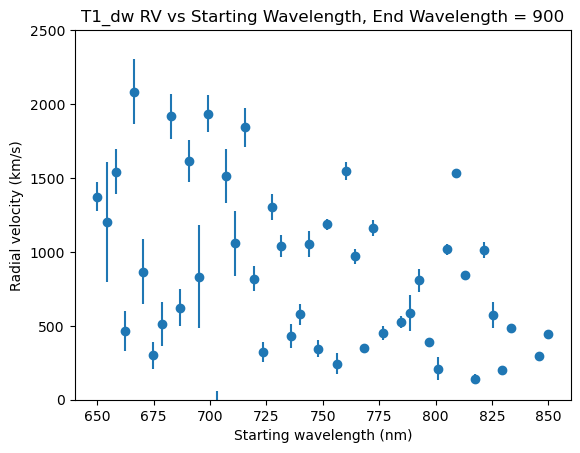

In [76]:
start_lams = np.array([r["start_lambda"] for r in results])
rvs        = np.array([r["rv"] for r in results])
ervs       = np.array([r["erv"] for r in results])
Rs         = np.array([r["R"] for r in results])

plt.figure()
plt.errorbar(start_lams * 1e9, rvs, yerr=ervs, fmt='o')
plt.xlabel("Starting wavelength (nm)")
plt.ylabel("Radial velocity (km/s)")
plt.title("T1_dw RV vs Starting Wavelength, End Wavelength = 900")
plt.ylim(0,2500)
plt.show()

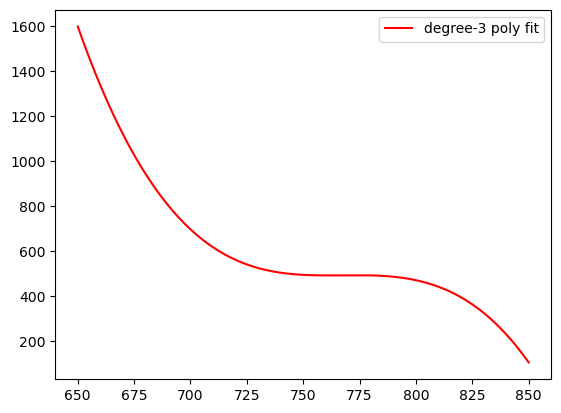

Polynomial coefficients (highest degree first): [-6.93916281e-04  1.59703097e+00 -1.22508808e+03  3.13724907e+05]


In [79]:
deg = 3  # adjust degree as needed
lams_nm = start_lams * 1e9
coeffs = np.polyfit(lams_nm, rvs, deg=deg, w=1/ervs)
dw_poly = np.poly1d(coeffs)

lam_fit = np.linspace(lams_nm.min(), lams_nm.max(), 300)
plt.plot(lam_fit, dw_poly(lam_fit), 'r-', label=f'degree-{deg} poly fit')
plt.legend()
plt.show()

print("Polynomial coefficients (highest degree first):", coeffs)

In [ ]:
results =[]

for sw in starting_wavelength:
    nuc = PyXCSAO(
        st_lambda=sw,
        end_lambda=9 * 10**-7,
        minvel=-2000,
        maxvel=2000,
    )
        
    nuc.data = nuc.format_spectrum(T1_nuc_tbl["flux"], T1_nuc_tbl["lambda"])
    hdul = fits.open(spec_files[0])
    nuc.meta = hdul[1].header
    nuc.add_grid(grid_pickle="std_grid.pkl")

    nuc_result = nuc.run_XCSAO(run_subgrid=False)

    rv_t1dw  = nuc_result["rv"] # rv km/s
    erv_t1dw = nuc_result["erv"] # rv error km/s
    r_t1dw   = nuc_result["r"] # Tonry & Davis R, signal-to-noise parameter of the correlation peak, higher is better.
    print(f"Starting lambda of {sw}: Radial velocity of T1_dw1907m6357: {rv_t1dw:.2f} ± {erv_t1dw:.2f} km/s, R={r_t1dw:.2f}")
    
    results.append({
        "start_lambda": sw,
        "rv": rv_t1dw,
        "erv": erv_t1dw,
        "R": r_t1dw,
    })

Starting lambda of 6.499999999999999e-07: Radial velocity of T1_dw1907m6357: 1640.16 ± 181.54 km/s, R=1.78
Starting lambda of 6.540816326530611e-07: Radial velocity of T1_dw1907m6357: 655.75 ± 186.74 km/s, R=1.65
Starting lambda of 6.581632653061224e-07: Radial velocity of T1_dw1907m6357: 1481.08 ± 213.23 km/s, R=2.06
Starting lambda of 6.622448979591836e-07: Radial velocity of T1_dw1907m6357: 827.53 ± 253.55 km/s, R=1.62
Starting lambda of 6.663265306122448e-07: Radial velocity of T1_dw1907m6357: 1703.95 ± 376.72 km/s, R=1.83
Starting lambda of 6.70408163265306e-07: Radial velocity of T1_dw1907m6357: 862.67 ± 261.02 km/s, R=1.88
Starting lambda of 6.744897959183673e-07: Radial velocity of T1_dw1907m6357: 1714.17 ± 278.95 km/s, R=1.64
Starting lambda of 6.785714285714285e-07: Radial velocity of T1_dw1907m6357: 683.10 ± 177.99 km/s, R=2.05
Starting lambda of 6.826530612244897e-07: Radial velocity of T1_dw1907m6357: 1708.42 ± 106.16 km/s, R=1.43
Starting lambda of 6.867346938775509e-07: 

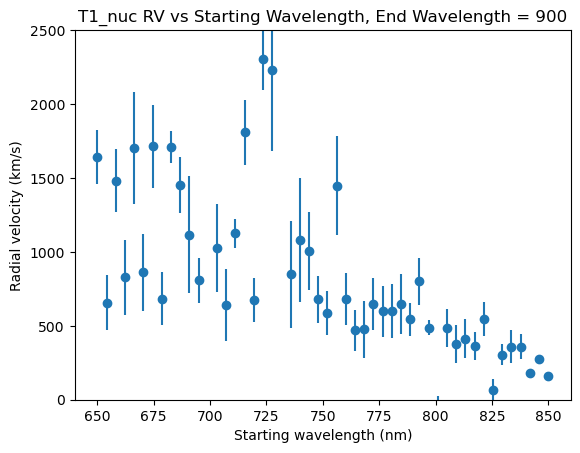

In [81]:
start_lams = np.array([r["start_lambda"] for r in results])
rvs        = np.array([r["rv"] for r in results])
ervs       = np.array([r["erv"] for r in results])
Rs         = np.array([r["R"] for r in results])

plt.figure()
plt.errorbar(start_lams * 1e9, rvs, yerr=ervs, fmt='o')
plt.xlabel("Starting wavelength (nm)")
plt.ylabel("Radial velocity (km/s)")
plt.ylim(0,2500)
plt.title("T1_nuc RV vs Starting Wavelength, End Wavelength = 900")
plt.show()

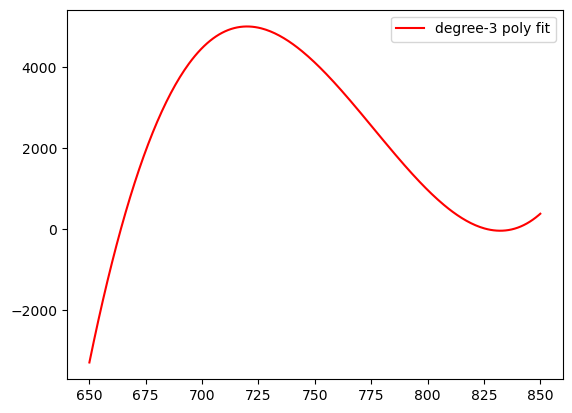

Polynomial coefficients (highest degree first): [ 7.10352297e-03 -1.65383961e+01  1.27676824e+04 -3.26560869e+06]


In [ ]:
deg = 3
lams_nm = start_lams * 1e9
coeffs = np.polyfit(lams_nm, rvs, deg=deg, w=1/ervs)
nuc_poly = np.poly1d(coeffs)

lam_fit = np.linspace(lams_nm.min(), lams_nm.max(), 300)
plt.plot(lam_fit, nuc_poly(lam_fit), 'r-', label=f'degree-{deg} poly fit')
plt.legend()
plt.show()

print("Polynomial coefficients (highest degree first):", coeffs)

In [49]:
ns = {'vo': 'http://www.ivoa.net/xml/VOTable/v1.4'}

tree = ET.parse('/Users/elliottburdett/Desktop/Midgard/NOIRLab_REU/NGC6744_group.xml')
root = tree.getroot()

# Get column names from FIELD elements
fields = root.findall('.//vo:FIELD', ns)
colnames = [f.attrib.get('name', f.attrib.get('ID', i)) for i, f in enumerate(fields)]

# Get data rows from TR/TD elements
rows = []
for tr in root.findall('.//vo:TR', ns):
    rows.append([td.text for td in tr.findall('vo:TD', ns)])

group_df = pd.DataFrame(rows, columns=colnames)
group_df

,Name,RAdeg,DEdeg,Bmag,Ksmag,Vh,D
0,NGC6744,287.4413,-63.8577,8.61,6.18,841,8.95
1,NGC6684,282.241,-65.1733,11.01,7.11,946,13.55
2,ESO141-042,289.0448,-62.361,13.22,10.6,921,None
3,NGC6684A,283.0933,-64.8323,12.75,10.84,1003,None
4,PGC166190,288.4728,-61.9136,16.78,11.87,946,None
5,ESO104-044,287.8461,-64.219,14.7,12.5,750,9.73
6,IC4824,288.3096,-62.0885,15.26,12.51,947,7.01
7,NGC6744A,287.1816,-63.7308,14.16,12.6,0,None
8,ESO104-022,283.9215,-64.8114,14.9,13,797,8.95
9,PGC2815832,286.7403,-63.9637,17.41,15.2,0,None


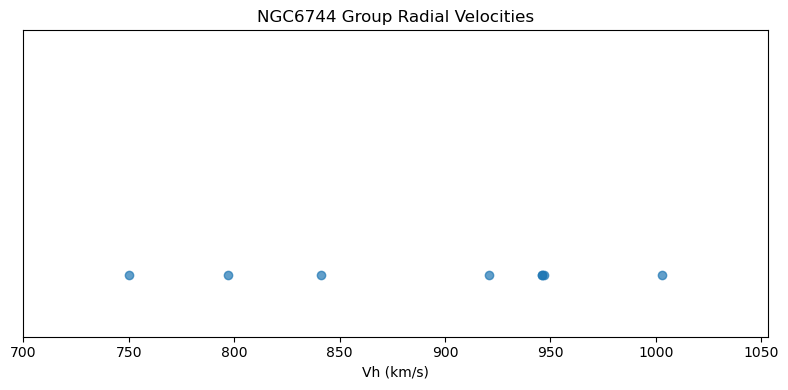

In [54]:
vh = group_df[group_df['Vh'].astype(float) != 0]['Vh'].astype(float)

fig, ax = plt.subplots(figsize=(8, 4))
ax.scatter(vh, [1]*len(vh), zorder=3, alpha=0.7)
ax.set_xlim(vh.min() - 50, vh.max() + 50)
ax.set_ylim(0, 5)
ax.set_xlabel('Vh (km/s)')
ax.set_yticks([])
ax.set_title('NGC6744 Group Radial Velocities')
plt.tight_layout()
plt.show()

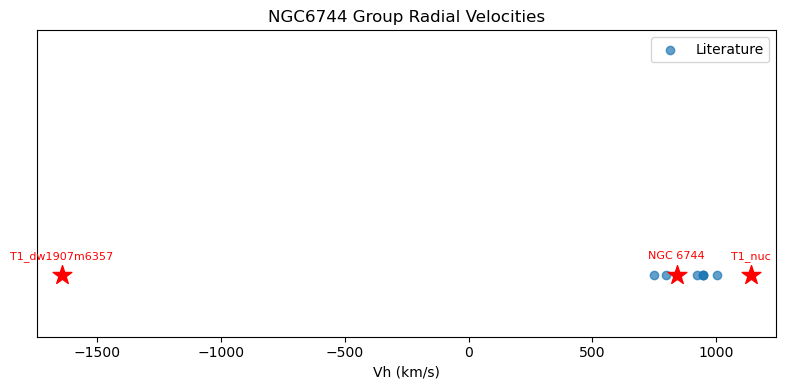

In [ ]:
vh = group_df[group_df['Vh'].astype(float) != 0]['Vh'].astype(float)

my_measurements = {
    'T1_dw1907m6357': -1643.11,
    'T1_nuc':          1141.81,
    'NGC 6744':       841 # from literature, just for reference
}

fig, ax = plt.subplots(figsize=(8, 4))

# Existing group members

# New measurements
for name, rv in my_measurements.items():
    ax.scatter(rv, 1, zorder=4, color='red', marker='*', s=200)
    ax.annotate(name, xy=(rv, 1), xytext=(0, 12),
                textcoords='offset points', ha='center', fontsize=8, color='red')
ax.scatter(vh, [1]*len(vh), zorder=3, alpha=0.7, label='Literature')

all_vals = list(vh) + list(my_measurements.values())
ax.set_xlim(min(all_vals) - 100, max(all_vals) + 100)
ax.set_ylim(0, 5)
ax.set_xlabel('Vh (km/s)')
ax.set_yticks([])
ax.set_title('NGC6744 Group Radial Velocities')
ax.legend()
plt.tight_layout()
plt.show()

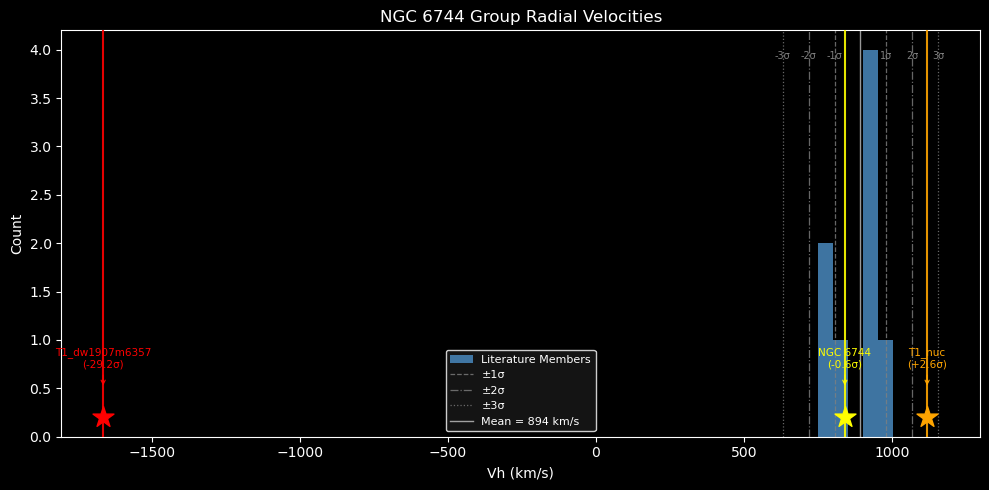

In [121]:
vh = group_df[group_df['Vh'].astype(float) != 0]['Vh'].astype(float)

my_measurements = {
    'T1_dw1907m6357': -1643.11 - 22.53,
    'T1_nuc':          1141.81 - 22.53,
    'NGC 6744':        841
}

mean_vh = vh.mean()
std_vh = vh.std()

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('black')
ax.set_facecolor('black')

# Histogram of known group members
ax.hist(vh, bins=5, color='steelblue', alpha=0.9, label='Literature Members', zorder=2)

# Sigma lines
for n, ls in zip([1, 2, 3], ['--', '-.', ':']):
    for sign in [-1, 1]:
        val = mean_vh + sign * n * std_vh
        ax.axvline(val, color='gray', linestyle=ls, linewidth=0.9, alpha=0.8,
                   label=f'±{n}σ' if sign == 1 else None)
        ax.text(val, ax.get_ylim()[1] * 0.95 if ax.get_ylim()[1] > 0 else 1,
                f'{sign*n}σ', color='gray', fontsize=7, ha='center', va='top')

# Mean line
ax.axvline(mean_vh, color='white', linestyle='-', linewidth=1, alpha=0.6, label=f'Mean = {mean_vh:.0f} km/s')

# New measurements
colors = ['red', 'orange', 'yellow']
for (name, rv), color in zip(my_measurements.items(), colors):
    ax.axvline(rv, color=color, linestyle='-', linewidth=1.5, alpha=0.9, zorder=5)
    ax.scatter(rv, 0.2, zorder=6, color=color, marker='*', s=250)
    sigma_offset = (rv - mean_vh) / std_vh
    ax.annotate(f'{name}\n({sigma_offset:+.1f}σ)', xy=(rv, 0.5),
                xytext=(0, 15), textcoords='offset points',
                ha='center', fontsize=7.5, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=0.8))

# Styling
for spine in ax.spines.values():
    spine.set_edgecolor('white')
ax.tick_params(colors='white')
ax.xaxis.label.set_color('white')
ax.yaxis.label.set_color('white')
ax.title.set_color('white')
ax.set_xlabel('Vh (km/s)')
ax.set_ylabel('Count')
ax.set_title('NGC 6744 Group Radial Velocities')
ax.legend(facecolor='#1a1a1a', edgecolor='white', labelcolor='white', fontsize=8)

plt.tight_layout()
plt.show()

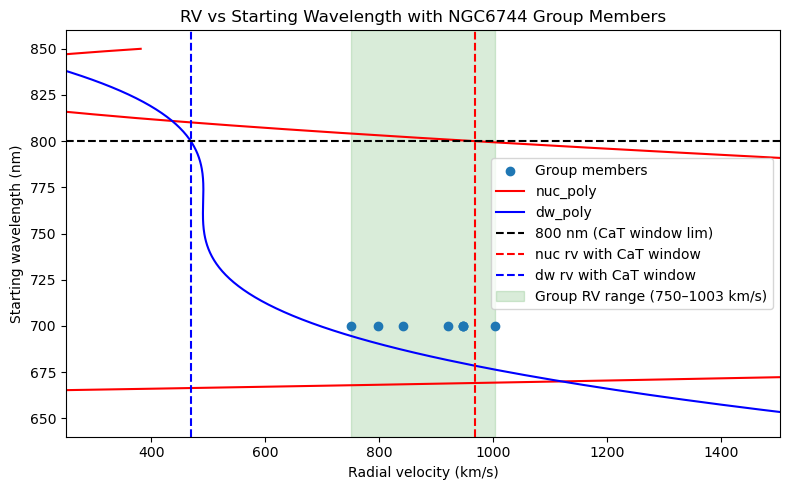

In [92]:
fig, ax = plt.subplots(figsize=(8, 5))

vh = group_df[group_df['Vh'].astype(float) != 0]['Vh'].astype(float)
ax.scatter(vh, [700]*len(vh), zorder=3, label='Group members')

lam_fit = np.linspace(lams_nm.min(), lams_nm.max(), 300)

ax.plot(nuc_poly(lam_fit), lam_fit, 'r-', color='r', label='nuc_poly')
ax.plot(dw_poly(lam_fit), lam_fit, 'r-', color='b', label='dw_poly')


#ax.errorbar(rvs, lams_nm, xerr=ervs, fmt='o', color='tab:blue', label='Measured RVs')
ax.axhline(800, color='k', linestyle='--', label='800 nm (CaT window lim)')
ax.axvline(nuc_poly(800), color='r', linestyle='--', label='nuc rv with CaT window')
ax.axvline(dw_poly(800), color='b', linestyle='--', label='dw rv with CaT window')

ax.axvspan(vh.min(), vh.max(), alpha=0.15, color='green', label=f'Group RV range ({vh.min():.0f}–{vh.max():.0f} km/s)')

ax.set_xlim(vh.min() - 500, vh.max() + 500)

ax.set_xlabel('Radial velocity (km/s)')
ax.set_ylabel('Starting wavelength (nm)')
ax.set_title('RV vs Starting Wavelength with NGC6744 Group Members')
ax.legend()
plt.tight_layout()
plt.show()

### Plot group luminosity function

In [112]:
group_df

,Name,RAdeg,DEdeg,Bmag,Ksmag,Vh,D
0,NGC6744,287.4413,-63.8577,8.61,6.18,841,8.95
1,NGC6684,282.241,-65.1733,11.01,7.11,946,13.55
2,ESO141-042,289.0448,-62.361,13.22,10.6,921,None
3,NGC6684A,283.0933,-64.8323,12.75,10.84,1003,None
4,PGC166190,288.4728,-61.9136,16.78,11.87,946,None
5,ESO104-044,287.8461,-64.219,14.7,12.5,750,9.73
6,IC4824,288.3096,-62.0885,15.26,12.51,947,7.01
7,NGC6744A,287.1816,-63.7308,14.16,12.6,0,None
8,ESO104-022,283.9215,-64.8114,14.9,13,797,8.95
9,PGC2815832,286.7403,-63.9637,17.41,15.2,0,None


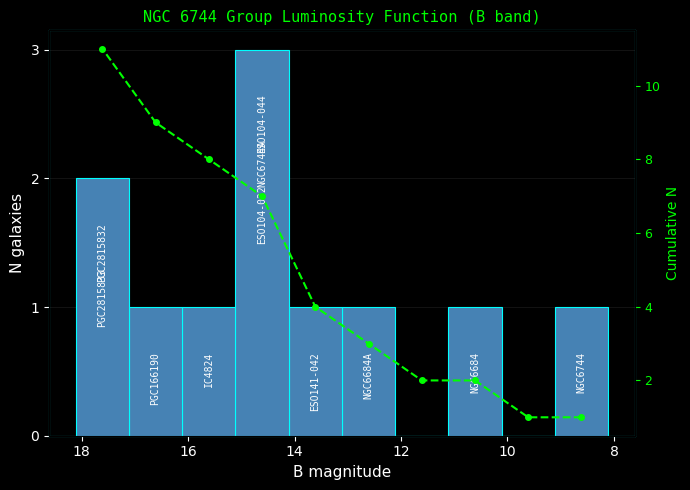


Confirmed members with Bmag: 11
      Name  Bmag   Vh
   NGC6744  8.61  841
   NGC6684 11.01  946
ESO141-042 13.22  921
  NGC6684A 12.75 1003
 PGC166190 16.78  946
ESO104-044 14.70  750
    IC4824 15.26  947
  NGC6744A 14.16    0
ESO104-022 14.90  797
PGC2815832 17.41    0
PGC2815833 17.46    0


In [ ]:
members = group_df#[group_df['Vh'].notna() & (group_df['Vh'] != '')].copy()
members['Bmag'] = pd.to_numeric(members['Bmag'], errors='coerce')
members = members.dropna(subset=['Bmag'])

mags = members['Bmag'].sort_values().values

bin_width = 1.0
bins = np.arange(mags.min() - 0.5, mags.max() + 1.5, bin_width)

fig, ax = plt.subplots(figsize=(7, 5), facecolor='black')
ax.set_facecolor('black')
for spine in ax.spines.values():
    spine.set_edgecolor('cyan')
ax.tick_params(colors='white', labelsize=10)

counts, edges, patches = ax.hist(mags, bins=bins, color='steelblue',
                                 edgecolor='cyan', linewidth=0.8, zorder=3)

for i, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
    in_bin = members[(members['Bmag'] >= left) & (members['Bmag'] < right)]
    for j, (_, row) in enumerate(in_bin.iterrows()):
        ax.text((left + right) / 2, counts[i] - 0.35 - j*0.35,
                row['Name'], color='white', fontsize=7,
                ha='center', va='top', fontfamily='monospace', rotation=90)

cumulative = np.cumsum(counts)
ax2 = ax.twinx()
ax2.plot(edges[:-1] + bin_width/2, cumulative, color='lime',
         lw=1.5, ls='--', marker='o', markersize=4, zorder=4)
ax2.set_ylabel('Cumulative N', color='lime', fontsize=10)
ax2.tick_params(colors='lime', labelsize=9)
ax2.set_facecolor('black')

ax.set_xlabel('B magnitude', color='white', fontsize=11)
ax.set_ylabel('N galaxies', color='white', fontsize=11)
ax.set_title('NGC 6744 Group Luminosity Function (B band)',
             color='lime', fontsize=11, fontfamily='monospace')
ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
ax.grid(axis='y', color='gray', alpha=0.2, lw=0.5)

ax.invert_xaxis()

plt.tight_layout()
plt.show()

print(f'\nConfirmed members with Bmag: {len(members)}')
print(members[['Name', 'Bmag', 'Vh']].to_string(index=False))